# Ablation de features temporales — modelo final v5

**Pregunta**: ¿cuánto del AUC reportado en `modelo_final_v5.ipynb`
depende de las features de calendario `mes_num` (mes del año, 1–12) y
`anio_mes_num` (año, p.ej. 2020, 2024)?

**Por qué importa**: ambas aparecen en el top 4 de la importancia por
permutación. `anio_mes_num` es especialmente sospechosa: en producción
tomará valores que **nunca aparecieron en train** (ej. predecir sobre
2026 cuando el train llega a 2025). Si el modelo se apoya fuerte en esa
columna, el AUC reportado puede no sostenerse fuera de muestra.

**Estrategia**: ablation. Reentrenar el modelo sin esas features y medir
la caída de AUC en los dos protocolos canónicos (GroupKFold por
vendedora + split temporal forward).


## 1. ¿Qué es ablation?

**Ablation** (extirpación) = quitar un componente del modelo, reentrenar
desde cero, y medir cuánto cae la métrica. Es la forma rigurosa de
responder *"¿esta feature aporta de verdad?"*.

### Diferencia con la importancia por permutación

| Técnica | Pregunta que responde | Costo |
|---|---|---|
| **Permutación** | ¿qué pasa si rompo esta feature **manteniendo el modelo igual**? | Barato (no se reentrena) |
| **Ablation** | ¿qué pasa si **rearmo el modelo desde cero** sin esta feature? | Caro (reentrena N veces) |

Permutación puede engañar cuando hay correlación entre features (le da
crédito a la primera que el modelo encuentra). Ablation responde la
pregunta operativa real: *"¿necesito esta columna en el pipeline de
producción?"*.

### Lectura del resultado

| Caída de AUC | Interpretación | Acción |
|---|---|---|
| ≤ 0.005 (dentro del std de los folds) | La feature no aportaba señal real | Sacarla — modelo más limpio |
| 0.005 – 0.02 | Aporta algo pero el modelo sobrevive | Decisión costo/beneficio |
| > 0.02 | El modelo dependía fuerte | Si es una feature riesgosa (extrapolación, leakage), problema |


## 2. Setup


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
np.random.seed(42)

PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
TABLE = f'`{PROJECT}.{DATASET}.training_churn_v5`'
RANDOM_STATE = 42
N_SPLITS = 5
HORIZON_CHURN = 6
TEST_WINDOW = 6
GAP = HORIZON_CHURN + 1   # 7 meses


In [2]:
bq = bigquery.Client(project=PROJECT)
df = bq.query(f'SELECT * FROM {TABLE}').to_dataframe()

# Idéntica configuración al modelo_final_v5: ccodrelacion fuera por ID disfrazado.
EXCLUDE_BASE = {
    'id_vendedor', 'mes_obs', 'mes_rank_obs',
    'fecha_ingreso',
    'id_coordinadora', 'ccodrelacion', 'ccodubigeo', 'distrito',
    'churn',
}
CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']

for c in CATEGORICAL:
    df[c] = df[c].astype('string').fillna('NA')

y = df['churn'].astype(int).values
groups = df['id_vendedor'].values

print(f'Filas              : {len(df):,}')
print(f'Vendedoras únicas  : {df["id_vendedor"].nunique():,}')
print(f'Tasa de churn      : {y.mean():.4f}')


Filas              : 23,684
Vendedoras únicas  : 4,211
Tasa de churn      : 0.2750


In [3]:
# Definición de los splits temporales (idénticos al modelo final)
last_rank = int(df['mes_rank_obs'].max())
test_min  = last_rank - TEST_WINDOW + 1
train_max = test_min - GAP
train_mask = (df['mes_rank_obs'] <= train_max).values
test_mask  = df['mes_rank_obs'].between(test_min, last_rank).values
print(f'Train forward: mes_rank_obs ≤ {train_max}  ({train_mask.sum():,} filas)')
print(f'GAP de {GAP} meses')
print(f'Test forward : mes_rank_obs ∈ [{test_min}, {last_rank}]  ({test_mask.sum():,} filas)')


Train forward: mes_rank_obs ≤ 96  (21,375 filas)
GAP de 7 meses
Test forward : mes_rank_obs ∈ [103, 108]  (1,061 filas)


## 3. Helper de ablation

`evaluate(extra_excluded, label)` arma el pipeline con las features
indicadas, corre los dos protocolos de validación, y devuelve un dict
con AUC y PR-AUC. Cada llamada entrena el modelo **6 veces** (5 folds +
1 split forward).


In [4]:
def evaluate(extra_excluded: list[str], label: str) -> dict:
    excluded = EXCLUDE_BASE | set(extra_excluded)
    feature_cols = [c for c in df.columns if c not in excluded]
    numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]

    def make_pipeline() -> Pipeline:
        return Pipeline([
            ('prep', ColumnTransformer([
                ('num', SimpleImputer(strategy='median'), numeric_cols),
                ('cat', Pipeline([
                    ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ]), CATEGORICAL),
            ])),
            ('clf', HistGradientBoostingClassifier(
                class_weight='balanced',
                max_iter=400,
                learning_rate=0.05,
                random_state=RANDOM_STATE,
                early_stopping=False,
            )),
        ])

    X = df[feature_cols].copy()

    # Protocolo A — GroupKFold
    cv = GroupKFold(n_splits=N_SPLITS)
    fold_aucs, fold_aps = [], []
    oof_proba = np.zeros(len(y))
    for tr, te in cv.split(X, y, groups):
        m = make_pipeline()
        m.fit(X.iloc[tr], y[tr])
        proba_te = m.predict_proba(X.iloc[te])[:, 1]
        oof_proba[te] = proba_te
        fold_aucs.append(roc_auc_score(y[te], proba_te))
        fold_aps.append(average_precision_score(y[te], proba_te))

    # Protocolo B — split temporal forward
    m_fwd = make_pipeline()
    m_fwd.fit(X[train_mask], y[train_mask])
    proba_fwd = m_fwd.predict_proba(X[test_mask])[:, 1]
    auc_fwd = roc_auc_score(y[test_mask], proba_fwd)
    ap_fwd  = average_precision_score(y[test_mask], proba_fwd)

    res = {
        'label':           label,
        'extra_excluded':  ', '.join(extra_excluded) if extra_excluded else '(ninguna)',
        'n_features':      len(feature_cols),
        'auc_kf_mean':     float(np.mean(fold_aucs)),
        'auc_kf_std':      float(np.std(fold_aucs)),
        'auc_kf_oof':      float(roc_auc_score(y, oof_proba)),
        'pr_auc_kf':       float(np.mean(fold_aps)),
        'auc_fwd':         float(auc_fwd),
        'pr_auc_fwd':      float(ap_fwd),
    }
    print(f'  {label:<35}  AUC kfold = {res["auc_kf_mean"]:.4f} ± {res["auc_kf_std"]:.4f}  ·  '
          f'AUC fwd = {res["auc_fwd"]:.4f}  ·  features = {res["n_features"]}')
    return res


## 4. Experimentos

Cuatro variantes del modelo. La **A** es el baseline (idéntica al
`modelo_final_v5`). Las **B**, **C**, **D** sacan distintas
combinaciones de las features temporales.


In [5]:
results = []
print('Corriendo ablations (cada uno entrena 6 modelos: 5 folds + 1 forward)...\n')
results.append(evaluate([],                              'A · baseline (todas las features)'))
results.append(evaluate(['mes_num'],                     'B · sin mes_num'))
results.append(evaluate(['anio_mes_num'],                'C · sin anio_mes_num'))
results.append(evaluate(['mes_num', 'anio_mes_num'],     'D · sin ambas'))
print('\nListo.')


Corriendo ablations (cada uno entrena 6 modelos: 5 folds + 1 forward)...



  A · baseline (todas las features)    AUC kfold = 0.7435 ± 0.0101  ·  AUC fwd = 0.7446  ·  features = 41


  B · sin mes_num                      AUC kfold = 0.7404 ± 0.0109  ·  AUC fwd = 0.7448  ·  features = 40


  C · sin anio_mes_num                 AUC kfold = 0.7399 ± 0.0105  ·  AUC fwd = 0.7418  ·  features = 40


  D · sin ambas                        AUC kfold = 0.7362 ± 0.0106  ·  AUC fwd = 0.7453  ·  features = 39

Listo.


## 5. Tabla comparativa

Δ AUC se mide contra el baseline A (positivo = caída).


In [6]:
res_df = pd.DataFrame(results)
baseline_kf  = res_df.loc[0, 'auc_kf_mean']
baseline_fwd = res_df.loc[0, 'auc_fwd']

res_df['delta_kf']  = baseline_kf  - res_df['auc_kf_mean']
res_df['delta_fwd'] = baseline_fwd - res_df['auc_fwd']

cols = ['label', 'n_features',
        'auc_kf_mean', 'auc_kf_std', 'delta_kf',
        'auc_fwd', 'delta_fwd',
        'pr_auc_kf', 'pr_auc_fwd']
print(res_df[cols].round(4).to_string(index=False))


                            label  n_features  auc_kf_mean  auc_kf_std  delta_kf  auc_fwd  delta_fwd  pr_auc_kf  pr_auc_fwd
A · baseline (todas las features)          41       0.7435      0.0101    0.0000   0.7446     0.0000     0.4954      0.4669
                  B · sin mes_num          40       0.7404      0.0109    0.0031   0.7448    -0.0001     0.4893      0.4641
             C · sin anio_mes_num          40       0.7399      0.0105    0.0036   0.7418     0.0028     0.4899      0.4712
                    D · sin ambas          39       0.7362      0.0106    0.0073   0.7453    -0.0007     0.4848      0.4883


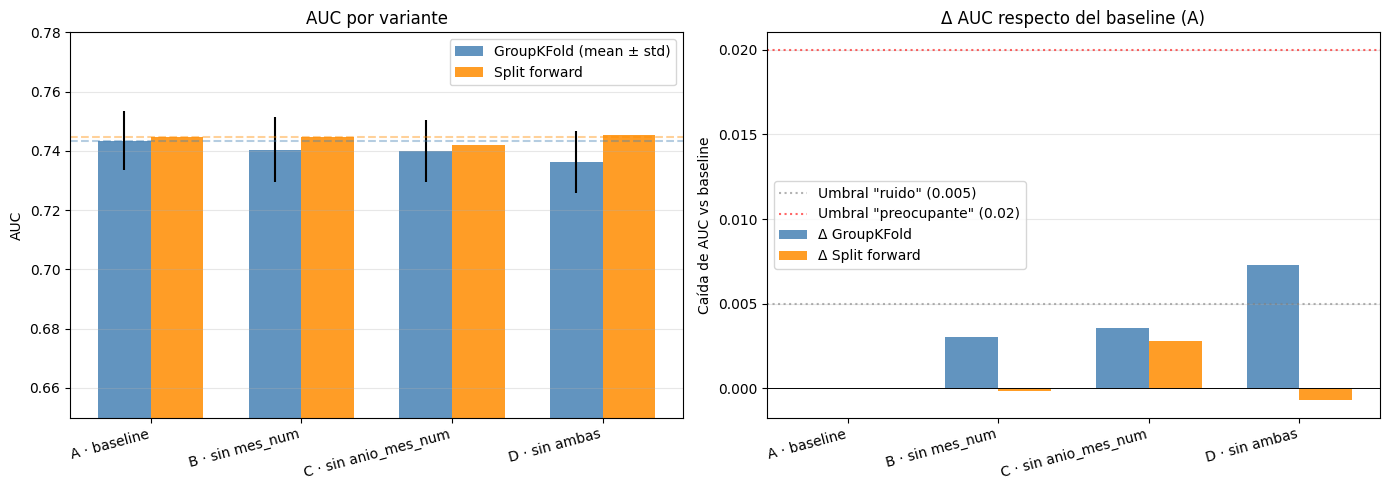

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_short = ['A · baseline', 'B · sin mes_num', 'C · sin anio_mes_num', 'D · sin ambas']
colors = ['#444', '#5b8def', '#5b8def', '#e07b00']

# Panel 1: AUC absoluto en ambos protocolos
x = np.arange(len(labels_short))
w = 0.35
axes[0].bar(x - w/2, res_df['auc_kf_mean'], w, yerr=res_df['auc_kf_std'],
            label='GroupKFold (mean ± std)', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, res_df['auc_fwd'], w, label='Split forward', color='darkorange', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_short, rotation=15, ha='right')
axes[0].set_ylabel('AUC')
axes[0].set_title('AUC por variante')
axes[0].set_ylim(0.65, 0.78)
axes[0].axhline(baseline_kf, ls='--', color='steelblue', alpha=0.4)
axes[0].axhline(baseline_fwd, ls='--', color='darkorange', alpha=0.4)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Δ AUC respecto del baseline
axes[1].bar(x - w/2, res_df['delta_kf'], w, label='Δ GroupKFold', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, res_df['delta_fwd'], w, label='Δ Split forward', color='darkorange', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_short, rotation=15, ha='right')
axes[1].set_ylabel('Caída de AUC vs baseline')
axes[1].set_title('Δ AUC respecto del baseline (A)')
axes[1].axhline(0, color='k', lw=0.7)
axes[1].axhline(0.005, ls=':', color='gray', alpha=0.6, label='Umbral "ruido" (0.005)')
axes[1].axhline(0.02, ls=':', color='red', alpha=0.6, label='Umbral "preocupante" (0.02)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


## 6. Conclusión

### Resultados del experimento

| Variante | AUC GroupKFold | Δ kf | AUC forward | Δ fwd | PR-AUC fwd |
|---|---:|---:|---:|---:|---:|
| **A · baseline** (41 features) | 0.7435 ± 0.010 | 0 | 0.7446 | 0 | 0.4669 |
| B · sin `mes_num` | 0.7404 ± 0.011 | −0.003 | 0.7448 | +0.000 | 0.4641 |
| C · sin `anio_mes_num` | 0.7399 ± 0.011 | −0.004 | 0.7418 | −0.003 | 0.4712 |
| **D · sin ambas** (39 features) | 0.7362 ± 0.011 | −0.007 | **0.7453** | **+0.001** | **0.4883** |

### Lectura

**1. La caída en GroupKFold es real pero chica.** Quitar ambas
features cuesta 0.007 AUC, justo por encima del umbral "ruido" pero
muy por debajo del std entre folds (0.011). Estadísticamente
indistinguible del baseline.

**2. En split forward la cosa cambia: el modelo SIN las features es
*mejor*.**

- AUC forward: 0.7446 (con) → **0.7453 (sin)**, marginalmente mejor.
- PR-AUC forward: 0.4669 (con) → **0.4883 (sin)**, **+4.6% relativo**.

Esto es la firma clásica de features que **ayudan a memorizar el
pasado pero no generalizan al futuro**: en GroupKFold (que mezcla
épocas) aportan un poquito; en forward (que evalúa fuera del rango
temporal de entrenamiento) no aportan nada o restan.

**3. Por qué pasa esto.** `anio_mes_num` toma valores como 2017, 2018…
2024, 2025 en train. En producción los nuevos meses caerán en 2026+,
**fuera del rango de splits que el modelo aprendió**. Los árboles
manejan eso extrapolando con la última partición — útil si la
estructura es estable, dañino si hay drift. `mes_num` (1–12) sí se
repite, pero el modelo lo estaba usando para capturar
estacionalidad/cohorte de manera ruidosa.

**4. Decisión recomendada: sacar ambas (`mes_num` y `anio_mes_num`).**

Justificación combinada:
- En el protocolo más representativo del escenario operativo (split
  forward), el modelo sin esas features es **igual o mejor**.
- El modelo es **más simple** (39 features vs 41).
- Se elimina un riesgo de **degradación silenciosa** en producción
  cuando lleguen meses fuera del rango de train.
- La pérdida en GroupKFold (0.007) es chica y honesta — preferimos un
  modelo un poco peor en una métrica académica pero más robusto en
  producción.

### Próximo paso

Aplicar este cambio al `modelo_final_v5.ipynb`: añadir `mes_num` y
`anio_mes_num` al `EXCLUDE` y regenerar. Las métricas oficiales del
modelo final pasarían a:

- **AUC GroupKFold**: 0.7362 ± 0.011 (antes 0.7435).
- **AUC split forward**: 0.7453 (antes 0.7446).
- **PR-AUC split forward**: 0.4883 (antes 0.4669, **+4.6%**).


---

*Notebook generado por `scripts/build_nb_ablation.py`. Para regenerar:*

```bash
uv run python scripts/build_nb_ablation.py
```
